In [11]:
from utils import load_and_prepare_data, structured_prune_hidden, benchmark_cpu, pruning_sweep
from neural_network import *
from sklearn.metrics import classification_report
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

numerical_cols = [
        "duration",
        "dst_bytes",
        "missed_bytes",
        "src_bytes",
        "src_ip_bytes",
        "src_pkts",
        "dst_pkts",
        "dst_ip_bytes",
        "http_request_body_len",
        "http_response_body_len"

    ]

categorical_cols = [
        "proto",
        "conn_state",
        "http_status_code",
        "http_method",
        "http_orig_mime_types",
        "http_resp_mime_types",
    ]


target_col = 'type'
num_target_classes = 6
dataset_path = 'datasets/http_ton.csv'
batch_size = 2048
epochs = 20
values_to_remove = {'type': ['mitm', 'dos']}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [12]:
train_dataloader, valid_dataloader, test_dataloader, cat_cardinalities, cw, target_names = load_and_prepare_data(
    file_path=dataset_path,
    target_col=target_col,
    numerical_cols=numerical_cols,
    categorical_cols=categorical_cols,
    batch_size=batch_size,
    rows_to_remove=values_to_remove
)

embedding_dims = [min(50, (card + 1) // 2) for card in cat_cardinalities]

In [13]:
# model = NeuralNetwork.load('best_model.pt', device=device)

In [14]:
model = NeuralNetwork(
    hidden_layers_sizes=[512, 256, 128], 
    cat_cardinalities=cat_cardinalities,
    embedding_dims=embedding_dims,
    num_numerical_features=len(numerical_cols),
    num_target_classes=num_target_classes,
)

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.85, patience=5)

In [16]:
model.fit(
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    device=device,
    optimizer=optimizer,
    lr_scheduler=scheduler,
    epochs=epochs,
    weights=cw
)

--- Epoch: 0  |  Loss: 0.3052  |  F1 Score: 0.7560  |  Accuracy: 0.8639 ---
--- Epoch: 1  |  Loss: 0.1940  |  F1 Score: 0.8533  |  Accuracy: 0.9399 ---
--- Epoch: 2  |  Loss: 0.2050  |  F1 Score: 0.8632  |  Accuracy: 0.9423 ---
--- Epoch: 3  |  Loss: 0.1215  |  F1 Score: 0.9221  |  Accuracy: 0.9665 ---
--- Epoch: 4  |  Loss: 0.1056  |  F1 Score: 0.9213  |  Accuracy: 0.9697 ---
--- Epoch: 5  |  Loss: 0.0896  |  F1 Score: 0.9299  |  Accuracy: 0.9738 ---
--- Epoch: 6  |  Loss: 0.0918  |  F1 Score: 0.9279  |  Accuracy: 0.9720 ---
--- Epoch: 7  |  Loss: 0.0807  |  F1 Score: 0.9445  |  Accuracy: 0.9753 ---
--- Epoch: 8  |  Loss: 0.0786  |  F1 Score: 0.9355  |  Accuracy: 0.9757 ---
--- Epoch: 9  |  Loss: 0.0708  |  F1 Score: 0.9461  |  Accuracy: 0.9786 ---
--- Epoch: 10  |  Loss: 0.0720  |  F1 Score: 0.9409  |  Accuracy: 0.9786 ---
--- Epoch: 11  |  Loss: 0.0699  |  F1 Score: 0.9135  |  Accuracy: 0.9718 ---
--- Epoch: 12  |  Loss: 0.0526  |  F1 Score: 0.9496  |  Accuracy: 0.9831 ---
--- Epoch

In [17]:
y_true = torch.cat([y for _, _, y in test_dataloader]).numpy()

In [18]:
df = pruning_sweep(
    base_model=model,
    train_loader=train_dataloader,
    valid_loader=valid_dataloader,
    test_loader=test_dataloader,
    class_weights=cw,
    device=device,
    finetune_epochs=10,    
    finetune_lr=5e-4,
    num_threads_bench=8,
    warmup=30, iters=2000
)

--- Epoch: 0  |  Loss: 0.0341  |  F1 Score: 0.9635  |  Accuracy: 0.9895 ---
--- Epoch: 1  |  Loss: 0.0372  |  F1 Score: 0.9607  |  Accuracy: 0.9881 ---
--- Epoch: 2  |  Loss: 0.0365  |  F1 Score: 0.9552  |  Accuracy: 0.9879 ---
--- Epoch: 3  |  Loss: 0.0406  |  F1 Score: 0.9610  |  Accuracy: 0.9882 ---
--- Epoch: 4  |  Loss: 0.0367  |  F1 Score: 0.9530  |  Accuracy: 0.9874 ---
--- Epoch: 5  |  Loss: 0.0401  |  F1 Score: 0.9640  |  Accuracy: 0.9879 ---
--- Epoch: 6  |  Loss: 0.0317  |  F1 Score: 0.9664  |  Accuracy: 0.9901 ---
--- Epoch: 7  |  Loss: 0.0335  |  F1 Score: 0.9585  |  Accuracy: 0.9894 ---
--- Epoch: 8  |  Loss: 0.0319  |  F1 Score: 0.9673  |  Accuracy: 0.9900 ---
--- Epoch: 9  |  Loss: 0.0303  |  F1 Score: 0.9699  |  Accuracy: 0.9906 ---
--- Epoch: 0  |  Loss: 0.0580  |  F1 Score: 0.9148  |  Accuracy: 0.9756 ---
--- Epoch: 1  |  Loss: 0.0337  |  F1 Score: 0.9653  |  Accuracy: 0.9903 ---
--- Epoch: 2  |  Loss: 0.0365  |  F1 Score: 0.9597  |  Accuracy: 0.9881 ---
--- Epoch: 3

In [19]:
df.to_csv("pruning_sweep_results.csv", index=False)
print(df[["neurons_kept_pct","hidden_shape","f1_macro","median_ms","throughput_sps","model_MB","params_M"]])

   neurons_kept_pct     hidden_shape  f1_macro  median_ms  throughput_sps  \
0        100.000000  [512, 256, 128]  0.970443   5.588835    3.646440e+05   
1         89.955357  [461, 230, 115]  0.966440   4.423890    4.525162e+05   
2         80.022321  [410, 205, 102]  0.963270   4.264458    4.846110e+05   
3         69.977679   [358, 179, 90]  0.957276   3.036927    6.661053e+05   
4         60.044643   [307, 154, 77]  0.965499   2.324007    8.633176e+05   
5         50.000000   [256, 128, 64]  0.956819   1.662814    1.139301e+06   
6         39.955357   [205, 102, 51]  0.959318   1.248172    1.550265e+06   
7         30.022321    [154, 77, 38]  0.958125   1.658095    1.191638e+06   
8         19.977679    [102, 51, 26]  0.941565   1.213666    1.745745e+06   
9         10.044643     [51, 26, 13]  0.920079   0.503003    3.715443e+06   

   model_MB  params_M  
0  0.694607  0.182087  
1  0.568111  0.148927  
2  0.456268  0.119608  
3  0.354820  0.093014  
4  0.267635  0.070159  
5  0.191

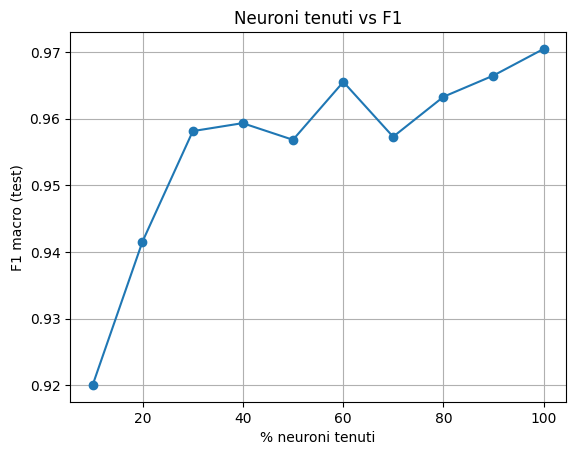

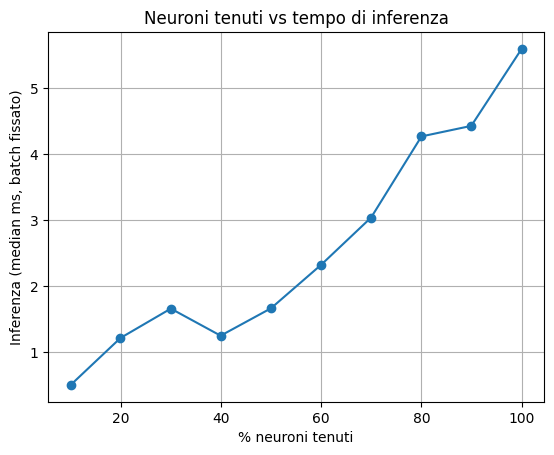

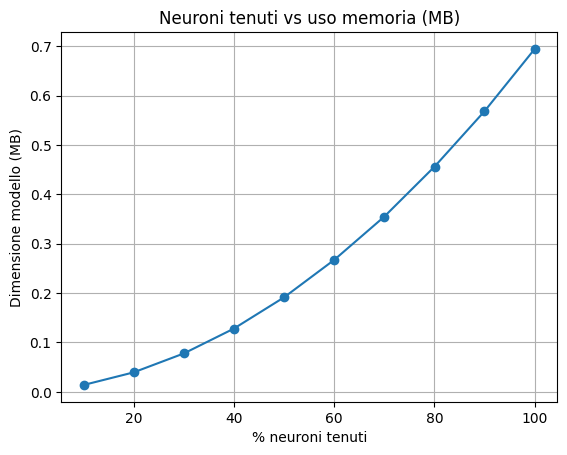

In [20]:
plt.figure()
plt.plot(df["neurons_kept_pct"], df["f1_macro"], marker="o")
plt.xlabel("% neuroni tenuti")
plt.ylabel("F1 macro (test)")
plt.title("Neuroni tenuti vs F1")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df["neurons_kept_pct"], df["median_ms"], marker="o")
plt.xlabel("% neuroni tenuti")
plt.ylabel("Inferenza (median ms, batch fissato)")
plt.title("Neuroni tenuti vs tempo di inferenza")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df["neurons_kept_pct"], df["model_MB"], marker="o")
plt.xlabel("% neuroni tenuti")
plt.ylabel("Dimensione modello (MB)")
plt.title("Neuroni tenuti vs uso memoria (MB)")
plt.grid(True)
plt.show()